# Wasserstein metric extrapolation and signed barycenters



In [1]:
# Prerequisites and compilation of Fortran code

!python3 build_fortran.py

Unknown vendor: "gfortran"
/home/andrea/.local/lib/python3.10/site-packages/numpy/f2py/f2py2e.py:734: VisibleDeprecationWarning: 
distutils has been deprecated since NumPy 1.26.x
Use the Meson backend instead, or generate wrappers without -c and use a custom build script
  builder = build_backend(
running build
running config_cc
INFO: unifying config_cc, config, build_clib, build_ext, build commands --compiler options
running config_fc
INFO: unifying config_fc, config, build_clib, build_ext, build commands --fcompiler options
running build_src
INFO: build_src
INFO: building extension "ot_sinkhorn" sources
INFO: f2py options: []
INFO: f2py:> /tmp/tmpy42_gqbl/src.linux-x86_64-3.10/ot_sinkhornmodule.c
creating /tmp/tmpy42_gqbl/src.linux-x86_64-3.10
Reading fortran codes...
	Reading file 'global.f90' (format:free)
	Reading file 'ot_sinkhorn.f90' (format:free)
Post-processing...
	Block: ot_sinkhorn
			Block: para
In: :ot_sinkhorn:global.f90:para
param_eval: got "eval() arg 1 must be a strin

INFO: x86_64-linux-gnu-gcc: /tmp/tmpy42_gqbl/src.linux-x86_64-3.10/ot_sinkhornmodule.c
INFO: x86_64-linux-gnu-gcc: /tmp/tmpy42_gqbl/src.linux-x86_64-3.10/fortranobject.c
INFO: compiling Fortran 90 module sources
INFO: Fortran f77 compiler: /usr/bin/gfortran -Wall -g -ffixed-form -fno-second-underscore -fPIC -O3 -funroll-loops
Fortran f90 compiler: /usr/bin/gfortran -Wall -g -fno-second-underscore -fPIC -O3 -funroll-loops
Fortran fix compiler: /usr/bin/gfortran -Wall -g -ffixed-form -fno-second-underscore -Wall -g -fno-second-underscore -fPIC -O3 -funroll-loops
INFO: compile options: '-I/tmp/tmpy42_gqbl/src.linux-x86_64-3.10 -I/home/andrea/.local/lib/python3.10/site-packages/numpy/_core/include -I/usr/include/python3.10 -c'
extra options: '-J/tmp/tmpy42_gqbl/ -I/tmp/tmpy42_gqbl/'
INFO: gfortran:f90: global.f90
INFO: gfortran:f90: ot_sinkhorn.f90
INFO: compiling Fortran sources
INFO: Fortran f77 compiler: /usr/bin/gfortran -Wall -g -ffixed-form -fno-second-underscore -fPIC -O3 -funroll-l

              g = mina_stab(c,f,mu,eps,[n,m])
            Constructing wrapper function "ot_sinkhorn.minb_stab"...
              f = minb_stab(c,g,nu,eps,[n,m])
            Constructing wrapper function "ot_sinkhorn.get_p"...
              p = get_p(f,g,c,mu,nu,eps,[n,m])
            Constructing wrapper function "ot_sinkhorn.gradient_deb_w2"...
              grad_self,fout_self,obj_self = gradient_deb_w2(d,nu,z,fin_self,eps,itmax,tol,fout_self,[m])
            Constructing wrapper function "ot_sinkhorn.ote_self"...
              fout_self,p,niter_self,errp_self,obj_self = ote_self(n,mu,c,fin_self,eps,itmax,tol,verb)
            Constructing wrapper function "ot_sinkhorn.mina_stab_self"...
              fnew = mina_stab_self(c,f,mu,eps,[n])
            Constructing wrapper function "ot_sinkhorn.cost_l2_self"...
              c = cost_l2_self(n,d,x)
            Constructing wrapper function "ot_sinkhorn.get_p_self"...
              p = get_p_self(f,c,mu,eps,[n])
		Constructing F90 modul

##  1. Computation of metric extrapolations with SISTA



**Problem formulation**: given $\nu_0,\nu_1 \in \mathcal{P}_2(\mathbb{R}^d)$ and $t>1$ we want to solve the metric extrapolation problem [2]:

$$
\tag{extrapolation}
\inf_{\mu} \, \left\{ \frac{ W^2_2\left(\mu, \nu_1 \right)}{2(t-1)} - \frac{W^2_2\left( \mu, \nu_0 \right)}{2t}\right\}
$$



**Discrete setting**: Given two vectors of positions $X = (x_1,\ldots,x_M)\in (\mathbb{R}^d)^M$ and  $Y = (y_1,\ldots,y_N)\in (\mathbb{R}^d)^N$ and masses $a =(a_1,\ldots,a_M) \in \mathbb{R}^M_+$ and $b = (b_1,\ldots,b_N) \in \mathbb{R}^N_+$,  we suppose that

$$
\nu_0 = \sum_{i=1}^M a_i \delta_{x_i}\quad \text{and} \quad \nu_1 = \sum_{j=1}^N b_j \delta_{y_j}
$$

Then, the solution will be in the form

$$
\mu = \sum_{j=1}^N b_j \delta_{z_j}
$$

with $Z= (z_1,\ldots,z_N) \in (\mathbb{R}^d)^N$ solving


$$\tag{1}
\inf_{Z} \, \left\{ \frac{ \| Z-Y \|^2_b}{2(t-1)} - \frac{1}{2t} W^2_2\left( \sum_{j=1}^N b_j \delta_{z_j},\sum_{i=1}^M a_i \delta_{x_i}\right) \right\} 
$$

where $\| Z\|^2_b = \sum_i |z_i|^2 b_i$.


**Entropic regularization**: In order to regularize the problem we replace $W_2$ in (1) with the entropy-regularized $W_2$ distance:

$$
\frac{1}{2}W_{2,\varepsilon}^2\left( \sum_{i=1}^N \frac{1}{N} \delta_{z_i},\sum_{i=1}^M a_i \delta_{x_i}\right) = \inf_{P \in \Pi(a,b)} \left\{\langle C,P\rangle + \varepsilon H(P|a\otimes b)\right\} \quad \text{ where }\quad C_{ij} = \frac{|z_i-x_j|^2}{2}
$$

By convex duality we also have:

$$
W_{2,\varepsilon}^2\left( \sum_{j=1}^N b_j\delta_{z_j},\sum_{i=1}^M \frac{1}{M} \delta_{x_i}\right) = \sup_{\phi\in \mathbb{R}^M,\psi \in \mathbb{R}^N }\sum_{i,j} -\varepsilon \exp\left( - \frac{|x_i-z_j|^2 - \phi_i - \psi_j}{2\varepsilon} \right)a_ib_j + \sum_i \phi_i a_i + \sum_j \psi_j b_j
$$

Therefore we are left to solve the problem

$$
\inf_{Z, \phi, \psi} \, f(Z,\phi,\psi)
$$

where $f$ is a smooth convex function:

$$
f(Z,\phi,\psi) = \sum_{ij}\left[ \frac{ |z_j-y_j|^2}{2(t-1)} + \frac{\varepsilon}{t} \exp\left( - \frac{|x_i-z_j|^2 - \phi_i - \psi_j}{2\varepsilon} \right) - \frac{\phi_i}{t} - \frac{\psi_j}{t}\right]a_ib_j
$$

**SISTA**. We apply the algorithm developed in <a href="ref1">[1]</a>. Given $\tau>0$, $Z^0,\psi^0$, for $k\geq 0$,

$$
\phi^{k+1} = \mathrm{argmin}_\phi f(Z^k,\phi,\psi^k) 
$$
$$
\psi^{k+1} = \mathrm{argmin}_\psi f(Z^k,\phi^{k+1},\psi) 
$$
$$
Z^{k+1} = Z^k - \tau  \nabla_Z f(Z^k,\phi^{k+1},\psi^{k+1}) 
$$

*Remark*. Note that in principle $\rho(D^2_Z f)$ scales as $\exp(1/\varepsilon)$, so one may expect that $\tau = \mathcal{O}(\exp(1/\varepsilon))$ for linear convergence. In fact, one can show <a href="ref2">[2]</a> that along the iterations the Lipschitz constant of $\nabla_Z f$ is $\mathcal{O}( \exp(\tau/\varepsilon)/\varepsilon)$. As a consequence one can prove linear convergence of the algorithm with a restriction $\tau \leq K \varepsilon$, for some explicit constant $K>0$ depending on the data, but not on $\varepsilon$. In practice, one can use an adaptive step size selection procedure (here we use Barzilai–Borwein selection rule).


<a id="ref1">[1]</a> Carlier, Dupuy, Galichon, Sun. SISTA: learning optimal transport costs under sparsity constraints.*Communications on Pure and Applied Mathematics*, 2023.

<a id="ref2">[2]</a> Gallouët, Natale, Todeschi. Metric extrapolation in the Wasserstein space. *Calculus of Variations and PDEs*, 2025.

In [8]:
import numpy as np
import extra_py_mod as extra
import ot_py_mod as ot
import ot_sinkhorn
import pickle
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import timeit
from dataclasses import dataclass
import warnings


In [9]:
T= 3# final time
Nt=3 # number of steps
dt=(T-1)/Nt
d=2 # dimension

In [10]:
@dataclass
class ExtrapParams:
    eps: float # temperature value
    deb: bool   # flag for diabising
    bb: bool   # flag for Barzilai-Borwein adaptive step size
    itmax: int # maximum number of iterations
    tol: float # tolerance
    tau: float # stepsize

params_extrap = ExtrapParams(
    eps= 1e-3,
    deb= False,
    bb = True,
    tau= None,
    itmax= 5000,
    tol= 1e-5)

In [11]:
filein='measures_small'
fileout='extrapolations_small'
#filein='measures'
#fileout='extrapolations'

In [12]:
file = open(filein, 'rb')
images=pickle.load(file)
file.close()

In [13]:
couples_all =[['cat','star8'],
         ['cat','trefle'],
         ['cat','thinspiral'],
         ['star8','trefle'],
         ['star8','thinspiral'],
         ['star8','cat'],
         ['thinspiral','cat'],
         ['thinspiral','star8'],
         ['thinspiral','trefle'],
         ['trefle','thinspiral'],
         ['trefle','cat'],
         ['trefle','star8']]

couples = [couples_all[0], couples_all[5]]

In [14]:
extrapolations = {}
start = timeit.default_timer()

for i0, i1 in couples:

    X, a = images[i0]
    Y, b = images[i1]
    extra_i = {0: (X, a), 1: (Y, b)}
    f0 = np.ones(X.shape[0])
    Z0 = Y

    for i in range(1, Nt + 1):

        t = 1 + i*dt

        f, g, Z, P, niter, errP, errG, obj = extra.extra(
            (X,a),(Y,b),f0,Z0,t,
            params_extrap.eps,
            params_extrap.deb,
            params_extrap.itmax,
            params_extrap.tol,
            params_extrap.tau,
            params_extrap.bb, verb= 0) 
                
        err_marg = errP[niter-1]
        err_grad = errG[niter-1]

        print(f"{(i0,i1)} iter={niter:4d} error_marg={err_marg:.2e} error_grad={err_grad:.2e}")

        if max(err_marg, err_grad) > params_extrap.tol:
            warnings.warn(
                f"{(i0,i1)} t={t:.4f}: error larger than tolerance "
                f"(error_marg={err_marg:.2e}, error_grad={err_grad:.2e})"
            )

        extra_i[t] = (Z, b, err_marg, err_grad)

        f0 = f
        Z0 = Z

    extrapolations[(i0, i1)] = extra_i

stop = timeit.default_timer()
print("Time:", stop - start)


('cat', 'star8') iter= 344 error_marg=9.69e-06 error_grad=1.84e-07
('cat', 'star8') iter= 371 error_marg=9.58e-06 error_grad=4.06e-07
('cat', 'star8') iter= 608 error_marg=9.46e-06 error_grad=3.17e-07
('star8', 'cat') iter= 533 error_marg=9.81e-06 error_grad=6.42e-08
('star8', 'cat') iter=2261 error_marg=9.94e-06 error_grad=4.03e-06
('star8', 'cat') iter=1305 error_marg=9.93e-06 error_grad=5.95e-06
Time: 3.5183973379999998


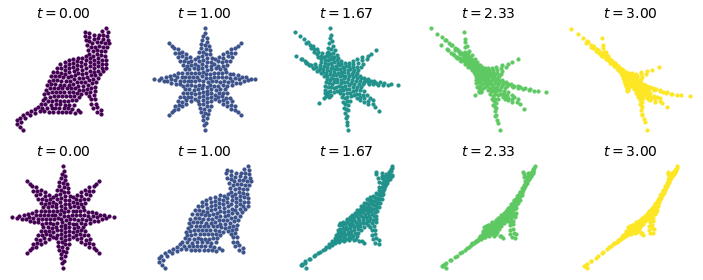

In [15]:
%matplotlib inline

cols = Nt + 2
rows = len(couples)

plt.figure(figsize=(cols*2., rows*2.))  

plot_idx = 1
for pair_name, extra_i in extrapolations.items():
    n_steps = len(extra_i)
    cmap = plt.get_cmap('viridis')  
    colors = [cmap(i / (n_steps - 1)) for i in range(n_steps)]
    
    for i, (time_key, value) in enumerate(extra_i.items()):
        array_data = value[0]
        
        ax = plt.subplot(rows, cols, plot_idx)
        ax.scatter(array_data[:,0], array_data[:,1], s=10, color=colors[i])
    
        ax.set_title(f"$t={time_key:.2f}$", fontsize=14)
        ax.set_aspect('equal')

        ax.axis('off')
        
        plot_idx += 1

plt.tight_layout()
plt.show()

### 1.1 Debiasing

Instead of using the entropic regularization of OT we'll use in the following the debiased Sinkhorn divergence

$$
\tilde{W}_{2,\varepsilon}^2(\mu,\nu)  = {W}_{2,\varepsilon}^2(\mu,\nu) - \frac{1}{2}{W}_{2,\varepsilon}^2(\mu,\mu)- \frac{1}{2}{W}_{2,\varepsilon}^2(\nu,\nu)\,.
$$

This is a symmetric positive definite, smooth loss function that is convex in
each of its input variables <a href="#ref3">[3]</a>. 

Let us look at the function

$$
F(Z) = \frac12 {W_{2,\varepsilon}^2\left( \sum_{j} b_j \delta_{z_j} ,\sum_{j} b_j \delta_{z_j} \right)}\,.
$$

Because of the dual formulation of $W_{2,\varepsilon}^2$ this is semi-convex funtion. In fact the modulus of semi-convexity is uniform in $\varepsilon$. More precisely, one can show that

$$
Z \mapsto F(Z) + \alpha \frac{\|Z\|^2_b}{2}
$$

is convex, for some $\alpha \leq  8 e^{ - 3/2}$. 

When using the debiased Sinkhorn divergence the extrapolation problem remains convex as long as

$$
\frac{1}{t-1} - \frac{1}{t} - \frac{\alpha}{2t} \geq 0 \quad \implies \quad t \leq t^* = \frac{\alpha+2} {\alpha}  \quad \text{where} \quad t^* \geq 2.12
$$



<a id="ref3">[3]</a>  Feydy, J., Séjourné, T., Vialard, F. X., Amari, S. I., Trouvé, A., & Peyré, G. (2019, April). Interpolating between optimal transport and mmd using sinkhorn divergences. In *The 22nd international conference on artificial intelligence and statistics* (pp. 2681-2690). PMLR.

## 2.  Quantization via metric extrapolation

### 2.1 Toland duality for the quantization problem

**Notation**: 

1. $Y = (y_1, \ldots,y_N) \in (\mathbb{R}^{d})^N$ is a vector of particles;
2. $b = (b_1,\ldots, b_N) \in \mathbb{R}^N_+$ is a vector of masses;
3. Weighted norm $\| Y \|^2_b := \sum_{i=1}^N {|y_i|^2}b_i$


**Problem formulation**: given $\mu \in \mathcal{P}_2(\mathbb{R}^d)$ we want to solve

$$
\inf_{Y} \, \frac{1}{2} W^2_2\left( \sum_{i=1}^N b \delta_{y_i}, \mu \right) = \inf_Y \left\{ \frac{\|Y\|^2_b}{2} - \mathrm{MCov} \left( \sum_{i=1}^N b_i \delta_{y_i}, \mu \right) + \frac{M_2(\mu)}{2} \right\} \,.
$$

By Toland duality, $Y$ is a solution if and only if it solves

$$
\inf_{Y}\left\{ - \frac{\|Y\|^2_b}{2} \,; \,   \sum_{i=1}^N b_i \delta_{y_i} \preceq_C \mu \right\}
$$

### 2.2 Implicit Euler scheme

$$
\text{Given $Y^0$, for $k \geq 0$: } \quad Y^{k+1} = \mathrm{argmin}_{Y}\left\{ \frac{\|Y - Y^k\|^2_b}{2\tau} - \frac{\|Y\|^2_b}{2} \,; \,   \sum_{i=1}^N b_i \delta_{y_i} \preceq_C \mu \right\}
$$

In other words setting $t = \tau^{-1}$, $Y^{k+1} = Z^{k+1} + \frac{t}{t-1}(Y^k - Z^{k+1})$ where

$$
\sum_{i=1}^N b_i \delta_{z_i^{k+1}} ~\text { is the extrapolation at time $t$ from $\mu$ to } ~\sum_{i=1}^N b_i \delta_{y_i^{k}}
$$

This is well-posed iff $\tau\leq1$. 

Other possible interpretation of the algorithm as DC optimization or gradient descent are possible <a href="#ref4">[4]</a>.

**Connection with Lloyd's algorithm** For $\tau=1$ and $\mu$ absolutely continuous, one recovers the classical Lloyd's algorithm for uniform quantization. In fact in this case we have

$$
Y^{k+1} = \mathrm{argmin}_{Y}\left\{ - \frac{\langle Y, Y^k \rangle_b}{2} \,; \,   \sum_{i=1}^N b_i \delta_{y_i} \preceq_C \mu \right\} = B(Y^k)
$$

where $B(Y^k)$ is the vector of barycenters $B(Y^k)_i = \frac{1}{b_i}\int_{L_i} x \mathrm{d} \mu(x)$ where $(L_i)_i$ is the optimal Laguerre tessellation defining the optimal transport from $\mu$ to $\sum_i b_i \delta_{y^k_i}$.

**Convergence** For $\tau<1$, any accumulation point of the discrete iterates $(Y^k)_k$ is a stationary point for arbitrary data $\mu \in \mathcal{P}_2(\mathbb{R}^d)$. Convergence of the whole sequence is a more delicate issue as for Lloyd's algorithm.  

**Entropic regularization** To implement the scheme we replace the extrapolation step by an entropic extrapolation as above. In this case, we are solving the entropic quantization problem:

$$
\inf_{Y} \, \frac{\beta}{2} S_{\varepsilon}\left( \sum_{i=1}^N b \delta_{y_i}, \mu \right) = \inf_X \left\{ \frac{\|Y\|^2_b}{2} - F(Y) \right\} \quad \text{where} \quad F(Y) = \frac{\|Y\|^2_b}{2}-\frac{\beta}{2} S_{\varepsilon}\left( \sum_{i=1}^N b \delta_{y_i}, \mu \right) \,.
$$

Here $S_\varepsilon$ is a Sinkhorn divergence (biased or not) and $\beta$ is chosen so that $F(Y)$ is convex ($\beta=1$ in the biased case). By Toland's duality, this is equivalent to 

$$
\inf_Y \left\{ F^*(Y) - \frac{\|Y\|^2_b}{2}\right\}
$$

In the implicit Euler scheme with time step $\tilde{\tau}$, given $Y^k$, $Y^{k+1}$ solves

$$
\mathrm{inf}_{Y} \left\{ \frac{\|Y - Y^k\|^2_b}{2\tilde{\tau}} - \frac{\|Y\|^2_b}{2}  + F^*(Y) \right\} = \sup_Z \left\{ \frac{\|Z - Y^k\|^2_b}{2(1-\tilde{\tau})} - \frac{\beta}{2} S_{\varepsilon}\left( \sum_{i=1}^N b \delta_{y_i}, \mu \right)  \right\}
$$

This is the same as for $\beta=1$, but for a time step $\tau = 1-\beta(1-\tilde{\tau})\in [1-\beta, 1)$. 


<a id="#ref4">[4]</a> Tim Hoheisel, Maxime Laborde, Adam Oberman. A regularization interpretation of the proximal point method for weakly convex functions. Journal of Dynamics and Games, 2020, 7(1): 79-96. doi: 10.3934/jdg.2020005 

In [16]:
# measure to be quantized
mu = images['cat']
X, a = mu

N0 = 20
X0 = np.random.rand(N0,2)-.5

In [17]:
@dataclass
class QuantParams:
    itmax: int # maximum number of iterations
    tol: float # tolerance
    tau: float # stepsize

params_quant = QuantParams(
    itmax = 2000,
    tol = 1e-3,
    tau = .8)

params_extrap = ExtrapParams(
    eps= 1e-3,
    deb = True,
    bb = True,
    tau= None,
    itmax= 50000,
    tol= 1e-7)

In [18]:
def uniformQuantizationSolver(mu,X0, params_quant, params_extrap, verb = True):
   
    X, _ = mu
    
    t = 1/params_quant.tau
  
    N0 = np.size(X0,0)
    Xk = X0.copy()   
    a0 = np.ones(N0)/N0

    error_history = []
    energy_history = []
    X_history = [Xk.copy()]

    i=0
    error = 100
    
    f0 = np.ones(np.shape(X)[0])
    print
    Z0 = X0.copy()
    
    while error >= params_quant.tol and i < params_quant.itmax:
        i+=1
        f, g, Z, P, niter, errP, errG, obj = extra.extra(mu,(Xk,a0),f0,Z0,t,
                                                             params_extrap.eps,
                                                             params_extrap.deb,
                                                             params_extrap.itmax,
                                                             params_extrap.tol,
                                                             params_extrap.tau,
                                                             0)
        Xk = Z + t/(t-1)*(Xk-Z)
        Z0 = Z.copy()
        f0 = f.copy()
        error = np.sqrt(np.linalg.norm(Xk-X_history[-1])/np.sqrt(N0))
        error_history.append(error)
        energy_history.append(-np.linalg.norm(Xk)**2/N0)

        X_history.append(Xk.copy())
        if verb: print(f"\rIteration {i}, Iterate difference {error}", end="", flush=True)
        

    return X_history, error_history, energy_history 



In [19]:
X_history, error_history, energy_history  = uniformQuantizationSolver(mu,X0, params_quant, params_extrap)

Iteration 281, Iterate difference 0.0009949275199066058

<IPython.core.display.Javascript object>


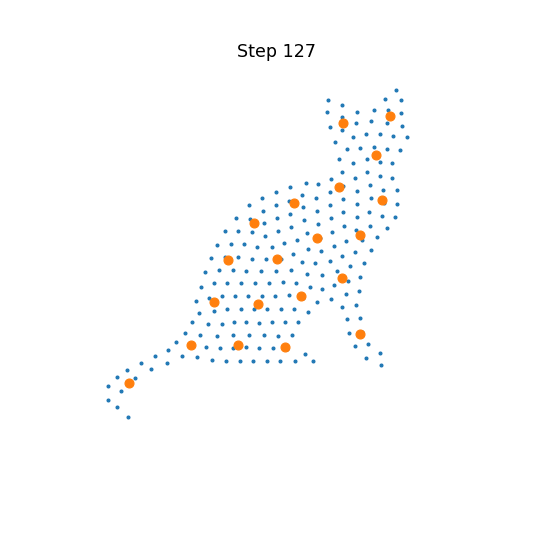

In [20]:
%matplotlib notebook

fig, ax = plt.subplots(figsize=(6,6))
ax.set_aspect('equal')
ax.axis('off')

# Fixed target measure
ax.scatter(X[:,0], X[:,1], s=5)

# Moving quantization points
scat = ax.scatter(X_history[0][:,0], X_history[0][:,1], s=50)

def update(frame):
    scat.set_offsets(X_history[frame])
    ax.set_title(f"Step {frame}", fontsize=14)
    return scat,

ani = FuncAnimation(
    fig,
    update,
    frames=len(X_history),
    interval=300,
    blit=True
)

plt.show()


In [21]:
X0 = np.random.rand(N0,2)-.5
params_extrap.eps = 1e-3
params_extrap.tau = .1
params_quant.tol = 2e-3

error_curves_debiased = []
energy_debiased = []
error_curves = []
energy = []
tau_vec = np.arange(.8,.99,.05)
for tau in tau_vec:
    params_quant.tau = tau
    
    print(f"\ntau : {tau:02f} ")
    
    params_extrap.deb = True
    X_history, error_history, energy_history  = uniformQuantizationSolver(mu,X0,
                                                                          params_quant,
                                                                          params_extrap)
    error_curves_debiased.append(error_history)
    energy_debiased.append(energy_history[-1])
    
    params_extrap.deb = False
    
    
    X_history, error_history, energy_history  = uniformQuantizationSolver(mu,X0,
                                                                          params_quant,
                                                                          params_extrap)

    error_curves.append(error_history)
    energy.append(energy_history[-1])


tau : 0.800000 
Iteration 251, Iterate difference 0.0019984457606051466
tau : 0.850000 
Iteration 245, Iterate difference 0.0019889889308183635
tau : 0.900000 
Iteration 242, Iterate difference 0.0019935899074779244
tau : 0.950000 
Iteration 264, Iterate difference 0.0019877776960030465

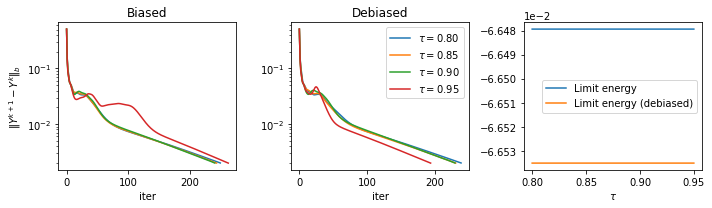

In [24]:
%matplotlib inline

fig, ax = plt.subplots(1,3, figsize=(10,3))
for curve in error_curves:
    ax[0].semilogy(curve)
for i,curve in enumerate(error_curves_debiased):
    ax[1].semilogy(curve, label = f"$\\tau={tau_vec[i]:.2f}$")

ax[2].plot(tau_vec, energy, label = 'Limit energy')
ax[2].plot(tau_vec, energy_debiased, label = 'Limit energy (debiased)')
ax[2].legend()
ax[2].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax[2].set_xlabel("$\\tau$")

ax[0].set_title('Biased')
ax[0].set_xlabel('iter')
ax[0].set_ylabel('$\|Y^{k+1} - Y^k\|_b$')
ax[1].set_xlabel('iter')
ax[1].set_title('Debiased')
ax[1].legend()
fig.tight_layout()


## 3. Signed barycenters with one positive coefficient


**Problem formulation**: given $\nu_0^q,\nu_1 \in \mathcal{P}_2(\mathbb{R}^d)$, $\lambda_q>0$ for $q=1,\ldots,Q$, such that $\sum_q \lambda_q =1$ and $t>1$ we consider the following signed barycenter problem

$$
\tag{$Q$ to 1 extrapolation}
\inf_{\mu} \, \left\{ \frac{ W^2_2\left(\mu, \nu_1 \right)}{2(t-1)} - \sum_{q=1}^Q \lambda_q \frac{W^2_2\left( \mu, \nu_0^q \right)}{2t}\right\}
$$

**Discrete regularized setting** Proceeding as before, in the discrete setting, we can restrict to $\mu$ in the form 
$
\sum_j b_j \delta_{z_j}
$. This leads us to the following equivalent formulation

$$
\inf_{Z} \, \left\{ \frac{ \| Z-Y \|^2_b}{2(t-1)} - \sum_{q=1}^Q \frac{\lambda_q}{2t} W^2_2\left( \sum_{j=1}^N b_j \delta_{z_j},\sum_{i=1}^{M_q} a_i^q \delta_{x_i^q}\right) \right\} 
$$

Replacing $W_2$ with the Sinkhorn divergence $\tilde{W}_{2,\varepsilon}$, and using the dual formulation of entropic OT we finally obtain

$$
\inf_{Z, \phi^q, \psi^q} \, f(Z,(\phi^q)_q,(\psi^q)_q)
$$

where $f$ is a smooth convex function:

$$
f(Z,\phi,\psi) = \sum_{ij}\left[ \frac{ |z_j-y_j|^2}{2(t-1)} + \frac{1}{t} \sum_q \lambda_q \left( 
\varepsilon\exp\left( - \frac{|x_i^q-z_j|^2 - \phi_i^q - \psi_j^q}{2\varepsilon} \right) - \phi_i^q - \psi_j^q
\right)a_i^q \right] b_j
$$

This can be solved just as before by an adaptation of the SISTA algorithm described above. 


In [ ]:
Nt= 5 # number of steps
dt=.1
d=2 # dimension

In [ ]:
params_extrap = ExtrapParams(
    eps= 1e-3,
    deb= True,
    tau= None,
    bb = True,
    itmax= 50000,
    tol= 1e-7)

In [ ]:
Nm=3
num=( images['cat'], images['thinspiral'], images['trefle']) #measures with negative coeff
nup= images['star8'] #measures with positive coeff
lm=np.array([1.0/3, 1.0/3, 1.0/3]) # weights for negative wasserstein distances

In [ ]:
extrapolations={}
start = timeit.default_timer()
extrapolations[0]= num
extrapolations[1]= nup

f0 = tuple([np.ones(num[k][0].shape[0]) for k in range(Nm)])
Z0 = nup[0]

for i in range(1, Nt + 1):

    t = 1 + i**2*dt

    f, g, Z, P, niter, errP, errG, obj = extra.extra_Nto1(num, nup, f0, Z0, t, lm, 
                                                                params_extrap.eps, 
                                                                params_extrap.deb, 
                                                                params_extrap.itmax, 
                                                                params_extrap.tol, 
                                                                params_extrap.tau,
                                                                params_extrap.bb, 0)

    err_marg = errP[niter-1]
    err_grad = errG[niter-1]

    print(f"iter={niter:4d} error_marg={err_marg:.2e} error_grad={err_grad:.2e}")

    if max(err_marg, err_grad) > params_extrap.tol:
        warnings.warn(
            f"t={t:.4f}: error larger than tolerance "
            f"(error_marg={err_marg:.2e}, error_grad={err_grad:.2e})"
        )

    extrapolations[t] = (Z, b , err_marg, err_grad)

    f0 = f
    Z0 = Z

stop = timeit.default_timer()
print("Time:", stop - start)


In [ ]:
cols = Nt + 2
rows = Nm

fig,ax =plt.subplots(Nm,Nt+2,figsize=(cols*2., rows*2.))  
cmap = plt.get_cmap('viridis')  
colors = [cmap(i / (Nt+2 - 1)) for i in range(Nt+2)]

for i, (time_key, value) in enumerate(extrapolations.items()):
   
    if i == 0:
        for j in range(Nm):
            
            array_data = value[j][0]
            ax[j,0].scatter(array_data[:,0], array_data[:,1], s=10, color=colors[i])
    
            ax[j,0].set_title(f"$t={time_key:.2f}$", fontsize=14)
            ax[j,0].set_aspect('equal')

            ax[j,0].axis('off')
            
    else:
        for j in range(Nm):
            ax[j,i].axis('off')

        array_data = value[0]
        ax[1,i].scatter(array_data[:,0], array_data[:,1], s=10, color=colors[i])
        ax[1,i].set_title(f"$t={time_key:.2f}$", fontsize=14)
        ax[1,i].set_aspect('equal')
        ax[1,i].axis('off')
            

### 3.1 Linearized barycenters

The discrete $Q$-to-1 extrapolation problem is convex in $Z$. Its dual problem reads as follows

$$
\inf_{\bar{X}}\left\{  \frac{\| Y- \bar{X} \|^2_b}{2}- \frac{\|\bar{X} \|^2_b}{2t} \,; \quad  \bar{X} = \sum_q \lambda_q \bar{X}^q \quad \text{where}\quad \sum_{i=1}^N b_i \delta_{\bar{x}_i^q} \preceq_C \mu^q \right\}
$$

and the optimal $Z$ and $\bar{X}$ are related by $\bar{X} = Z + \frac{t}{t-1}(Y-Z)$.

Consider the measure

$$
\overline{\nu}_0 = \sum_{i=1}^N b_i \delta_{\bar{x}_i}
$$

As $t \rightarrow 1 $, $\bar{\nu}_0 \rightarrow \bar{\nu}_0^*$ selects a "linearized barycenter" of the measures $\nu_0^q$ with base $\nu_1$, in the following sense

$$
\overline{\nu}_0^* :=  \arg\min \Big\{ \int |x|^2 \mathrm{d} \overline{\nu}_0(x) \, ;\;  \overline{\nu}_0 = \Big(\sum_k \lambda^k T^k\Big)_\# \nu_1\,, \,
\pi^k \in \Gamma^{\mathrm{opt}}(\nu^k_0,\nu_1) \Big\},
$$

where

$$
T^k(y) = \int x  \mathrm{d} \pi^k_y(x) \quad \text{and}\quad  \mathrm{d}\pi^k(x,y) = \mathrm{d} \pi^k_y(x) \mathrm{d} \nu_1(y) \,.
$$

In [ ]:
cols = Nt 
rows = 1

fig,ax =plt.subplots(1,Nt,figsize=(cols*2., rows*2.))  
cmap = plt.get_cmap('viridis')  
colors = [cmap(i / (Nt+2 - 1)) for i in range(Nt+2)]

for i, (time_key, value) in enumerate(extrapolations.items()):
   
    if i > 1: 
        
        array_data = (time_key*nup[0] - value[0])/(time_key-1)
        ax[i-2].scatter(array_data[:,0], array_data[:,1], s=10, color=colors[i])
        ax[i-2].set_title(f"$t={time_key:.2f}$", fontsize=14)
        ax[i-2].set_aspect('equal')
        ax[i-2].axis('off')
            

## 4. Particle approximation of Wasserstein barycenters


### 2.1 Toland duality for (classical) Wasserstein barycenters

**Problem formulation**: given $\mu \in \mathcal{P}_2(\mathbb{R}^d)$ we want to solve

$$
\inf_{Y} \, \sum_{q=1}^Q \frac{\lambda_q}{2} W^2_2\left( \sum_{i=1}^N b \delta_{y_i}, \mu^q \right) = \inf_Y \left\{ \frac{\|Y\|^2_b}{2} - \sum_q \lambda_q \left( \mathrm{MCov} \left( \sum_{i=1}^N b_i \delta_{y_i}, \mu^q \right) +  \frac{M_2(\mu^q)}{2} \right) \right\} \,.
$$

By Toland duality, $Y$ is a solution if and only if it solves

$$
\inf_{Y}\left\{ - \frac{\|Y\|^2_b}{2} \,; \quad  Y = \sum_q \lambda_q Y^q \quad \text{where}\quad \sum_{i=1}^N b_i \delta_{y_i^q} \preceq_C \mu^q \right\}
$$

### 2.2 Implicit Euler scheme

$$
\text{Given $Y^0$, for $k \geq 0$: } \quad Y^{k+1} = \mathrm{argmin}_{Y}\left\{ \frac{\|Y - Y^k\|^2_b}{2\tau} - \frac{\|Y\|^2_b}{2} \,; \,  \quad  Y = \sum_q \lambda_q Y^q \quad \text{where}\quad \sum_{i=1}^N b_i \delta_{y_i^q} \preceq_C \mu^q \right\}
$$

In other words setting $t = \tau^{-1}$, $Y^{k+1} = Z^{k+1} + \frac{t}{t-1}(Y^k - Z^{k+1})$ where

$$
\sum_{i=1}^N b_i \delta_{z_i^{k+1}} ~\text {is the $Q$-to-1 extrapolation at time $t$ from $(\mu^q,\lambda_q)_q$ to } ~\sum_{i=1}^N b_i \delta_{y_i^{k}}
$$

*Remark* In view of the connection with linearized Wasserstein barycenter described above, the scheme we obtained can be seen as a variant of <a href="#ref6">[5]<a>.

<a id="#ref6">[5]</a> Tanguy, Eloi, Julie Delon, and Nathaël Gozlan. "Computing barycentres of measures for generic transport costs." arXiv preprint arXiv:2501.04016 (2024).

In [ ]:
num=( images['cat'], images['star8'], images['trefle']) # measures to be averaged
lm=np.array([1.0/3, 1.0/3, 1.0/3]) # weights 

N0 = len(num[0][1])
X0 = np.random.rand(N0,2)-.5 # initialization for particle approximation of barycenter


In [ ]:
@dataclass
class BaryParams:
    itmax: int # maximum number of iterations
    tol: float # tolerance
    tau: float # stepsize

params_bary = BaryParams(
    itmax = 2000,
    tol = 1e-2,
    tau = .8)

params_extrap = ExtrapParams(
    eps= 5e-4,
    deb = True,
    tau= None,#20,
    bb= True,
    itmax= 50000,
    tol= 1e-7)

In [ ]:
def uniformBarycenterSolver(num,lm, X0, params_bary, params_extrap, verb = True):
   
    #X, _ = mu
    Nm = len(num)
    
    t = 1/params_bary.tau
  
    N0 = np.size(X0,0)
    Xk = X0.copy()   
    a0 = np.ones(N0)/N0

    error_history = []
    energy_history = []
    X_history = [Xk.copy()]

    i=0
    error = 100
    
    f0 = tuple([np.ones(num[k][0].shape[0]) for k in range(Nm)])
    Z0 = X0.copy()
    
    while error >= params_bary.tol and i < params_bary.itmax:
        i+=1
        
        f, g, Z, P, niter, errP, errG, obj = extra.extra_Nto1(num, (Xk,a0), f0, Z0, t, lm, 
                                                                params_extrap.eps, 
                                                                params_extrap.deb, 
                                                                params_extrap.itmax, 
                                                                params_extrap.tol, 
                                                                params_extrap.tau,
                                                                params_extrap.bb,0)
        
        
        Xk = Z + t/(t-1)*(Xk-Z)
        Z0 = Z.copy()
        f0 = f
        error = np.sqrt(np.linalg.norm(Xk-X_history[-1])/np.sqrt(N0))
        error_history.append(error)
        energy_history.append(-np.linalg.norm(Xk)**2/N0)

        X_history.append(Xk.copy())
        if verb: print(f"\rIteration {i}, Iterate difference {error}", end="", flush=True)
        

    return X_history, error_history, energy_history 

In [ ]:
X_history, error_history, energy_history  = uniformBarycenterSolver(num,lm,X0, params_bary, params_extrap)

In [ ]:
%matplotlib notebook

fig, ax = plt.subplots(figsize=(6,6))
ax.set_aspect('equal')
ax.axis('off')

# Fixed target measure
ax.scatter(num[0][0][:,0] -1, num[0][0][:,1]-.8, s=5)
ax.scatter(num[1][0][:,0]+1, num[1][0][:,1]-.8, s=5)
ax.scatter(num[2][0][:,0], num[2][0][:,1]+1.2, s=5)



# Moving quantization points
scat = ax.scatter(X_history[0][:,0], X_history[0][:,1], s=5)

def update(frame):
    scat.set_offsets(X_history[frame])
    ax.set_title(f"Step {frame}", fontsize=14)
    return scat,

ani = FuncAnimation(
    fig,
    update,
    frames=len(X_history),
    interval=300,
    blit=True
)

plt.show()

            

## 5. Particle approximation of signed Wasserstein barycenters

**Problem formulation**: given $\nu_0^q, \in \mathcal{P}_2(\mathbb{R}^d)$, $\lambda_q^->0$ for $q=1,\ldots,Q$, and $\nu_1^l \in \mathcal{P}_2(\mathbb{R}^d)$, $\lambda_l^+>0$ for $l=1,\ldots,L$, such that $\sum_q \lambda_q^- =1$, $\sum_l \lambda_l^+ =1$ and $t>1$, we consider the following signed barycenter problem


$$
\tag{$Q$ to $L$ extrapolation}
\inf_{\mu} \, \left\{ t \sum_{l=1}^L \lambda_l^+ \frac{ W^2_2\left(\mu, \nu_1^l \right)}{2} - (t-1)\sum_{q=1}^Q \lambda_q^- \frac{W^2_2\left( \mu, \nu_0^q \right)}{2}\right\}
$$

**Particle solutions**: We look for solutions in the form (in this case, this is a real constraint)

$$
\mu = \sum_{i=1}^N b_i \delta_{z_i}
$$

In this case, up to constant terms, the problem above can be written as follows:

$$
\tag{DC}
\inf_{Z} \left\{ \frac{\|Z\|_b^2}{2t} + F(Z) - G(Z) \right\}
$$

where

$$
G(Z) = \sum_{l=1}^L \lambda_l^+ \mathrm{MCov}\left( \sum_{i=1}^N b_i \delta_{z_i}, \nu_1^l \right) \,, \quad F(Z) = \frac{t-1}{t} \sum_{q=1}^Q \lambda_q^- \mathrm{MCov}\left( \sum_{i=1}^N b_i \delta_{z_i}, \nu_0^q \right)
$$

By Toland duality, we can solve the equivalent problem

$$
\inf_{Y} \left\{ G^*(Y)  - \left( \frac{\|\cdot\|_b^2}{2t} + F(\cdot) \right)^*(Y) \right\}
$$

Differently from before, an implicit Euler step on this functional requires the solution of a saddle point problem. 

### 5.1 A DC algorithm

We can solve (DC) with the following classical altenate optimization approach <a href="#ref5">[6]</a>: Given $Y^0 \in \mathrm{dom} \partial G$, for $k\geq 1$,

$$
Y^k \in \partial G(Z^{k-1}) \,,\quad Z^k \in \partial \tilde{F}^*(Y^k) \,, \quad \tilde{F}(\cdot) = \frac{\|\cdot\|_b^2}{2} + F(\cdot) 
$$

where $\partial$ denotes the subdifferential; we use here the weighted inner product $\langle X,Y\rangle_b = \sum_i \langle x_i,y_i\rangle b_i$.

**Subdifferential of $G$**

$$
\partial G(Z) =  \left\{ \sum_{l=1}^L \lambda_l^+ B^l(Z)\,, \quad \text{where} \quad B^l(Z)_j =  \int x \mathrm{d} \pi^l_{z_j}(x), \quad \mathrm{d}\pi^l(y,z) = \sum_j\delta_{z_j} \otimes \mathrm{d} \pi^l_{z_j}(y) ~\text{ optimal from $\nu_l^+$ to $\mu$}\right\}
 $$

**Subdifferential of $\tilde{F}^*$** Rearranging terms we find

$$
\tilde{F}^*(Y) = \frac{\|Y\|^2_b}{2} + \sup_Z \left\{-\frac{\|Z -Y\|^2_b}{2} +\frac{t-1}{2t} \sum_{q} \lambda_q^- W^2_2\left( \sum_j b_j \delta_{z_j} , \nu_0^q\right) \right\}
$$

$$
\nabla \tilde{F}^*(Y)= Z(Y) \,, \quad Z(Y)~\text{ unique solution to the $Q$-to-1 extrapolation problem above} 
$$

*Remark*. The algorithm computes alternatively a linearized barycenter of the positive measures with base the current estimate of the solution, and then extrapolates from the negative measures to such linearized barycenter to compute a new estimate of the solution.


<a id ="#ref6">[6]</a> Tao, Pham Dinh, and LT Hoai An. "Convex analysis approach to DC programming: theory, algorithms and applications." Acta mathematica vietnamica 22, no. 1 (1997): 289-355.

### 5.2 Signed barycenters with Sinkhorn divergences

We consider now the regularized problem where all Wasserstein distances are replaced by Sinkhorn divergences


$$
\tag{$Q$ to $L$ regularized extrapolation}
\inf_{\mu} \, \left\{ t \sum_{l=1}^L \lambda_l^+ \frac{ S_\varepsilon\left(\mu, \nu_1^l \right)}{2} - (t-1)\sum_{q=1}^Q \lambda_q^- \frac{S_\varepsilon \left( \mu, \nu_0^q \right)}{2}\right\}
$$

We can still formulate the problem as a difference of convex function, as above. This time we write for some $\theta>0$

$$
\tag{DC}
\inf_{Z} \left\{ \tilde{F}(Z) - \tilde{G}(Z)\right\}
$$

where

$$
\tilde{G}(Z) = \frac{\|Z\|_b^2}{2} - \frac{t}{t+\theta}\sum_{l=1}^L \lambda_l^+ S_\varepsilon \left( \sum_{i=1}^N b_i \delta_{z_i}, \nu_1^l \right) \,, \quad \tilde{F}(Z) =  \frac{\|Z\|_b^2}{2}  - \frac{t-1}{t+\theta} \sum_{q=1}^Q \lambda_q^- S_\varepsilon\left( \sum_{i=1}^N b_i \delta_{z_i}, \nu_0^q \right)
$$


**Convexity of $\tilde{F}$ and $\tilde{G}$**. Let $\alpha$ be the modulus of semi-convexity of the self-transport term as above. Note that $\tilde{G}$ is convex as long as

$$
1 - \frac{t}{t+\theta}\left(1+\frac\alpha2\right) \geq 0 \implies \theta \geq t\frac{\alpha}{2}
$$

This also guarantees that $\tilde{F}$ is strongly convex, since for $\theta \geq t\alpha/2$ we have that  

$$
1 - \frac{t-1}{t+\theta}\left(1+\frac\alpha2\right) \geq \frac{1}{t+\theta} \left(1+\frac\alpha2\right) \geq 0
$$


**Subdifferential of $\tilde{F}$** Let us observe that setting

$$
s = \frac{t+\theta}{1+\theta} \implies \frac{s-1}{s} = \frac{t-1}{t+\theta}
$$

Therefore, this time


$$
    \tilde{F}^*(Y) = \frac{\|Y\|^2_b}{2} + \sup_Z \left\{-\frac{\|Z -Y\|^2_b}{2} +\frac{s-1}{2s} \sum_{q} \lambda_q^- S_\varepsilon \left( \sum_j b_j \delta_{z_j} , \nu_0^q\right) \right\}
$$

$$
\nabla \tilde{F}^*(Y)= Z(Y) \,, \quad Z(Y)~\text{ unique solution to the $Q$-to-1 extrapolation problem above} 
$$

Note that for $\theta \geq t \alpha/2$, we automatically have $s \leq t^*$.

**Subdifferential of $G$**

$$
\partial \tilde{G}(Z) = Z  - \frac{t}{t+\theta} \left( -\sum_{l=1}^L \lambda^+_l B^l(Z) + B^{\mathrm{self}}(Z)\right) $$

where $B^l(Z)$ is defined as above replacing OT plans with entropic OT plans, and  $B^{\mathrm{self}}(Z)$ corresponds to the self-transport term.

In [ ]:
num=( images['star8'],images['star8']) #measures with negative coeff
nup=( images['cat'], images['trefle']) #measures with positive coeff
lm=np.array([1.0/2, 1.0/2]) # weights for negative wasserstein distances
lp=np.array([1.0/2, 1.0/2]) # weights for positive wasserstein distances

@dataclass
class SignedBaryParams:
    itmax: int # maximum number of iterations
    tol: float # tolerance
    theta: float # stepsize

params_signedbary = SignedBaryParams(
    itmax = 2000,
    tol = 1e-2,
    theta = 1.)

params_extrap = ExtrapParams(
    eps= 1e-3,
    deb = True,
    tau= 10.,
    itmax= 50000,
    bb = False,
    tol= 1e-7)


t =  2.
params_signedbary.theta = t*3.6/2
N0 = 200
X0 = np.random.rand(N0,2)-.5 

In [ ]:
def uniformSignedBarycenterSolver(num,lm, nup,lp, X0, params_signedbary, params_extrap, verb = True):
   
    Nm = len(num)
    Np = len(nup)
    N0 = np.size(X0,0)
    Xk = X0.copy()   
    a0 = np.ones(N0)/N0

    error_history = []

    i=0
    error = 100
    
    f0 = tuple([np.ones(num[k][0].shape[0]) for k in range(Nm)])
    Z0 = X0.copy()
    Z_history = [Z0.copy()]
    
    s =  (t + params_signedbary.theta)/(1+params_signedbary.theta)
    
    while error >= params_signedbary.tol and i < params_signedbary.itmax:
        i+=1
        
        # get Xk linearized barycenter
        baryplus = np.zeros(X0.shape)
        for j in range(Np):
            _, grad = ot.Sdiv(nup[j],(Z0,a0),cost=ot_sinkhorn.ot_sinkhorn.cost_l2,eps=params_extrap.eps,itmax=10000,tol=5e-4,verb=0)
            baryplus += lp[j]*grad
            
        Xk = Z0 - t*(Z0 - baryplus.copy())/(t+ params_signedbary.theta)    
        
        
        
        f, g, Z, P, niter, errP, errG, obj = extra.extra_Nto1(num, (Xk,a0), f0, Z0, s, lm, 
                                                                params_extrap.eps, 
                                                                params_extrap.deb, 
                                                                params_extrap.itmax, 
                                                                params_extrap.tol, 
                                                                params_extrap.tau,
                                                                params_extrap.bb,0)
        
        
        
        Z0 = Z.copy()
        f0 = f
        error = np.sqrt(np.linalg.norm(Z0-Z_history[-1])/np.sqrt(N0))
        error_history.append(error)

        Z_history.append(Z0.copy())
        if verb: print(f"\rIteration {i}, Iterate difference {error}", end="", flush=True)
        

    return Z_history, error_history

In [ ]:
Z_history, error_history = uniformSignedBarycenterSolver(num,lm, nup,lp, X0, params_signedbary, params_extrap, verb = True)

In [ ]:
%matplotlib notebook

fig, ax = plt.subplots(figsize=(6,6))
ax.set_aspect('equal')
ax.axis('off')

# Fixed target measure
ax.scatter(num[0][0][:,0] -1, num[0][0][:,1] -1, s=5)
ax.scatter(num[1][0][:,0] -1, num[1][0][:,1] +1, s=5)
ax.scatter(nup[0][0][:,0] +1, nup[0][0][:,1] -1, s=5)
ax.scatter(nup[1][0][:,0] +1, nup[1][0][:,1] +1, s=5)

# Moving quantization points
scat = ax.scatter(Z_history[0][:,0]+3., Z_history[0][:,1], s=5)

def update(frame):
    points = Z_history[frame].copy()
    points[:,0] += 3. 
    scat.set_offsets(points)
    ax.set_title(f"Step {frame}", fontsize=14)
    return scat,

ani = FuncAnimation(
    fig,
    update,
    frames=len(Z_history),
    interval=300,
    blit=True
)

plt.show()